# Vision Transformer (ViT-S/4) — CIFAR-10 Research Benchmark

Research-grade ViT trained **from scratch** on the full **CIFAR-10** dataset (50 000 training images, 3-channel 32×32)  
using the `dnp` autograd framework on an **NVIDIA L4 GPU** (22 GB VRAM, 53 GB RAM).

---

## Architecture — ViT-S/4 (Global Average Pooling variant)

```
Input image (3×32×32)
        │
┌─────────────────────────────────────────────────────────────────┐
│   Patch Embedding                                               │
│   4×4 patches  →  64 tokens,  patch_dim = 48                   │
│   Linear(48 → 256) + Learnable Positional Embedding (64 × 256) │
└─────────────────────────────────────────────────────────────────┘
        │  (B, 64, 256)
┌─────────────────────────────────────────────────────────────────┐
│  ×8  Pre-LN Transformer Encoder Blocks                          │
│  ├─ LayerNorm → Multi-Head Self-Attention (8 heads, d_k=32)     │
│  │  + Residual + Dropout(0.1)                                   │
│  └─ LayerNorm → FFN (256 → 512 → 256, GELU)                    │
│     + Residual + Dropout(0.1)                                   │
└─────────────────────────────────────────────────────────────────┘
        │  (B, 64, 256)
  Global Average Pooling → (B, 256)
        │
  LayerNorm → Linear Classifier → (B, 10)
```

| Hyperparameter | Value |
|---|---|
| Image size | 32×32 (RGB, 3 channels) |
| Patch size | 4×4 → **64 patches** |
| Patch dim | 48 |
| d\_model | **256** |
| Heads | **8**  (head\_dim = 32) |
| Depth | **8** Transformer blocks |
| MLP hidden | 512 |
| Dropout | 0.1 |
| Approx. params | ~4.2 M |

---

## Training Strategy

| Setting | Value |
|---|---|
| Dataset | **CIFAR-10** — 45 K train / 5 K val / 10 K test |
| Input dtype | **float32** (2× speedup vs float64) |
| Normalisation | Per-channel mean-std (CIFAR standard statistics) |
| Augmentation | Random crop (pad=4) + Random horizontal flip |
| Optimiser | **AdamW** lr = 1×10⁻³, weight\_decay = 0.05 |
| LR Schedule | Linear warm-up (10 ep) → **Cosine annealing** |
| Epochs | up to **200** (early-stop patience = 30) |
| Batch size | **256** |
| GPU backend | **CuPy** (CUDA 12.x on L4) |

> **Research target** — properly-tuned small ViT from scratch: **88–93 %** top-1 accuracy on CIFAR-10


In [1]:

# ── 0. Environment Setup ─────────────────────────────────────────────────
import subprocess, sys, os
from pathlib import Path

# ── GPU info ─────────────────────────────────────────────────────────────
print("── GPU info ────────────────────────────────────────────────────")
try:
    r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total,driver_version',
                        '--format=csv,noheader'], capture_output=True, text=True, timeout=10)
    for line in r.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"  {e}")

# ── Clone or pull repo (branch v3) ──────────────────────────────────────
REPO_DIR = Path('/content/AutoDiff-Numpy')
if not REPO_DIR.exists():
    print("\n── Cloning Seydifa/AutoDiff-Numpy (branch v3) ──────────────────")
    subprocess.run(
        ['git', 'clone', '--branch', 'v3', '--depth', '1',
         'https://github.com/Seydifa/AutoDiff-Numpy.git', str(REPO_DIR)],
        check=True,
    )
    print("  Cloned OK")
else:
    print(f"\n── Pulling latest changes in {REPO_DIR} ─────────────────────")
    result = subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'],
                            capture_output=True, text=True)
    print(f"  {result.stdout.strip() or result.stderr.strip()}")

# Add repo root to sys.path so 'dnp' is importable
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# ── Install CuPy for CUDA 12.x (NVIDIA L4) ───────────────────────────────
print("\n── Installing CuPy (CUDA 12.x) ─────────────────────────────────")
r2 = subprocess.run(['pip', 'install', 'cupy-cuda12x', '-q'],
                    capture_output=True, text=True, timeout=300)
if r2.returncode == 0:
    print("  cupy-cuda12x  installed OK")
else:
    print("  cupy install failed — will use NumPy CPU fallback")

# ── Install remaining deps ────────────────────────────────────────────────
print("\n── Installing remaining dependencies ────────────────────────────")
subprocess.run(['pip', 'install', 'scikit-learn', '-q'], check=False)
print("  scikit-learn OK")


── GPU info ────────────────────────────────────────────────────
  NVIDIA L4, 23034 MiB, 580.82.07

── Pulling latest changes in /content/AutoDiff-Numpy ─────────────────────
  Updating de8b19b..7125c06

── Installing CuPy (CUDA 12.x) ─────────────────────────────────
  cupy-cuda12x  installed OK

── Installing remaining dependencies ────────────────────────────
  scikit-learn OK


In [ ]:

# ── 1. Imports & global setup ──────────────────────────────────────────────
import sys, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

import dnp
from dnp.core.tensor import Tensor
from dnp.core.session import session
from dnp.core.backend import (
    is_cuda_available, get_dtype, set_dtype, as_numpy, backend, get_xp,
)
from dnp import ops

from dnp.layers import (
    Module, Sequential, Linear,
    LayerNorm, Dropout,
    SelfAttention, CrossEntropyLoss,
)
from dnp import Adam, AdamW, CosineAnnealingLR, WarmupScheduler

# ── Use float32: 2× faster + half the VRAM vs float64 ─────────────────────
set_dtype('float32')

DEVICE = 'cuda' if is_cuda_available else 'cpu'

print(f"dnp loaded  |  backend: {DEVICE.upper()}  |  dtype: {get_dtype().__name__}  |  NumPy {np.__version__}")
if is_cuda_available:
    import cupy as cp
    free, total = cp.cuda.runtime.memGetInfo()
    print(f"GPU VRAM:  {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")
else:
    print("Running on CPU — no CUDA device found")


dnp loaded  |  backend: CUDA  |  dtype: float32  |  NumPy 2.0.2
GPU VRAM:  23.5 GB free / 23.7 GB total



## 2. Dataset — CIFAR-10

**CIFAR-10** is a standard GPU benchmark consisting of **60 000 colour images** (32×32 RGB) across **10 object classes**:

> airplane · automobile · bird · cat · deer · dog · frog · horse · ship · truck

| Split | Samples |
|---|---|
| Train (used) | 45 000 |
| Validation | 5 000 |
| Test | 10 000 |

Pixel values are normalised with CIFAR-standard **per-channel** statistics:

```
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2023, 0.1994, 0.2010]
```


In [3]:

# ── 2. Load CIFAR-10 ────────────────────────────────────────────────────────
print("Loading CIFAR-10 ...")

# Try Keras first (available on Colab), fall back to torchvision
try:
    from tensorflow.keras.datasets import cifar10
    (X_tr_raw, y_tr_raw), (X_te_raw, y_te_raw) = cifar10.load_data()
    X_tr_raw = X_tr_raw.reshape(-1, 32, 32, 3)
    X_te_raw = X_te_raw.reshape(-1, 32, 32, 3)
    y_tr_raw = y_tr_raw.reshape(-1).astype(np.int32)
    y_te_raw = y_te_raw.reshape(-1).astype(np.int32)
    print("  Loaded via TensorFlow/Keras")
except ImportError:
    import torchvision, tempfile
    _dir = tempfile.mkdtemp()
    _tr = torchvision.datasets.CIFAR10(root=_dir, train=True,  download=True)
    _te = torchvision.datasets.CIFAR10(root=_dir, train=False, download=True)
    X_tr_raw = np.array(_tr.data)                              # (50000, 32, 32, 3)
    y_tr_raw = np.array(_tr.targets, dtype=np.int32)
    X_te_raw = np.array(_te.data)                              # (10000, 32, 32, 3)
    y_te_raw = np.array(_te.targets, dtype=np.int32)
    print("  Loaded via torchvision")

# ── Channel-first (N, C, H, W) + float32 ──────────────────────────────────
X_tr_hwc = X_tr_raw.astype(np.float32) / 255.0   # (50000, 32, 32, 3)
X_te_hwc = X_te_raw.astype(np.float32) / 255.0   # (10000, 32, 32, 3)

# CIFAR-10 standard channel statistics
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010], dtype=np.float32)

X_tr_hwc = (X_tr_hwc - CIFAR_MEAN) / CIFAR_STD   # normalise (still HWC)
X_te_hwc = (X_te_hwc - CIFAR_MEAN) / CIFAR_STD

# Transpose to channel-first
X_tr_nchw = X_tr_hwc.transpose(0, 3, 1, 2)       # (50000, 3, 32, 32)
X_te_nchw = X_te_hwc.transpose(0, 3, 1, 2)       # (10000, 3, 32, 32)

# ── Validation split (last 5 000 of training set) ─────────────────────────
X_val   = X_tr_nchw[-5_000:]
y_val   = y_tr_raw[-5_000:]
X_train = X_tr_nchw[:-5_000]
y_train = y_tr_raw[:-5_000]
X_test  = X_te_nchw
y_test  = y_te_raw

# Column-vector labels expected by CrossEntropyLoss
y_train_f = y_train.reshape(-1, 1).astype(np.float32)
y_val_f   = y_val.reshape(-1, 1).astype(np.float32)
y_test_f  = y_test.reshape(-1, 1).astype(np.float32)

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"\nTrain  : {X_train.shape}   labels: {y_train.shape}")
print(f"Val    : {X_val.shape}    labels: {y_val.shape}")
print(f"Test   : {X_test.shape}   labels: {y_test.shape}")
print(f"Classes: {CLASSES}")
print(f"dtype  : {X_train.dtype}")


Loading CIFAR-10 ...
  Loaded via TensorFlow/Keras

Train  : (45000, 3, 32, 32)   labels: (45000,)
Val    : (5000, 3, 32, 32)    labels: (5000,)
Test   : (10000, 3, 32, 32)   labels: (10000,)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
dtype  : float32


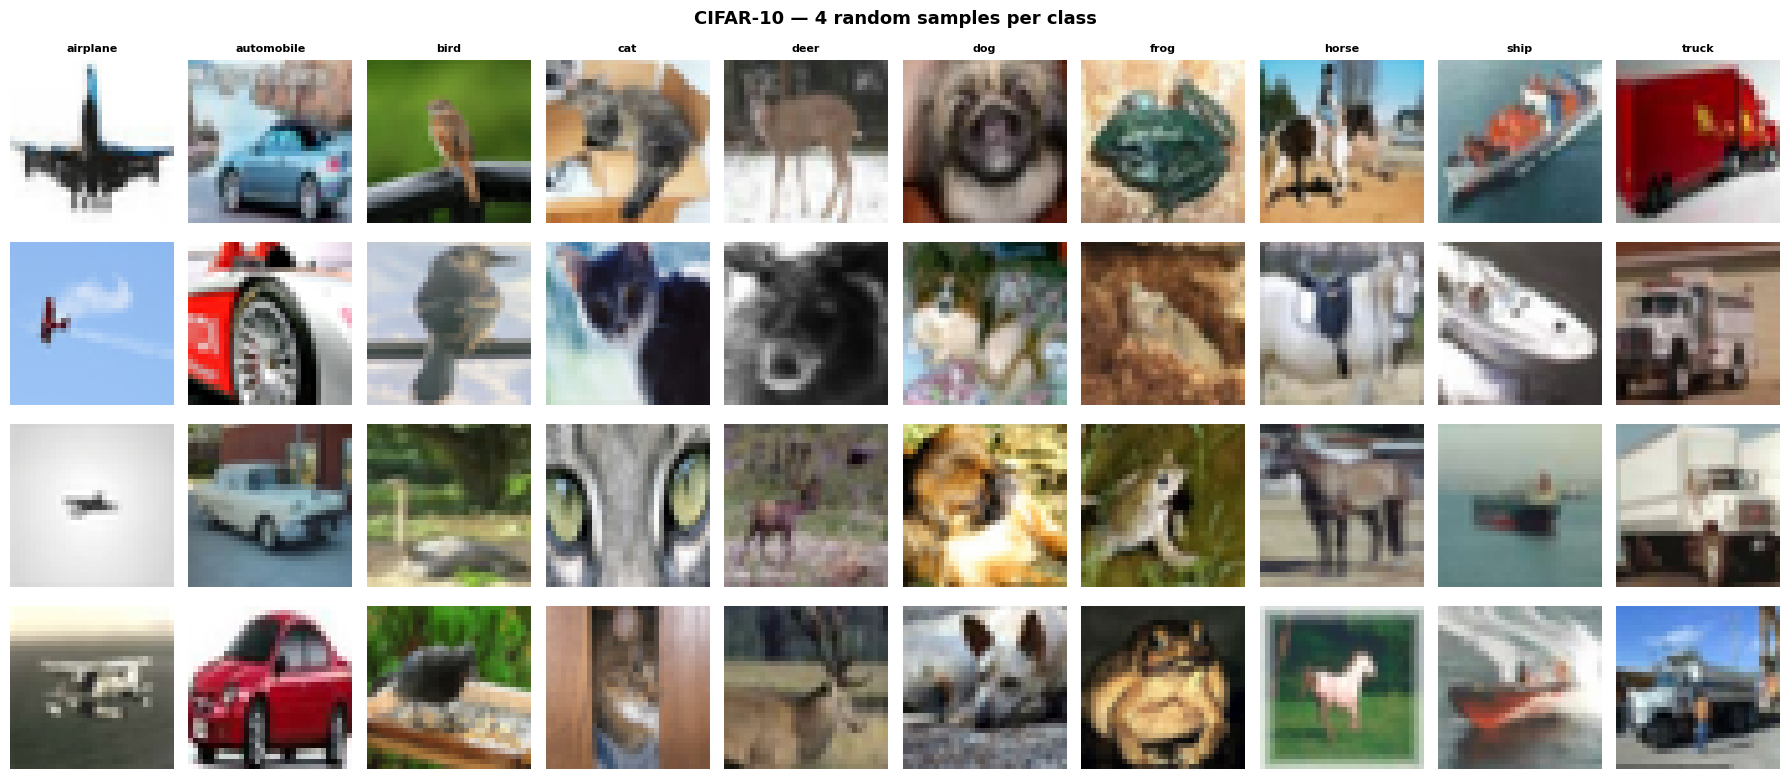

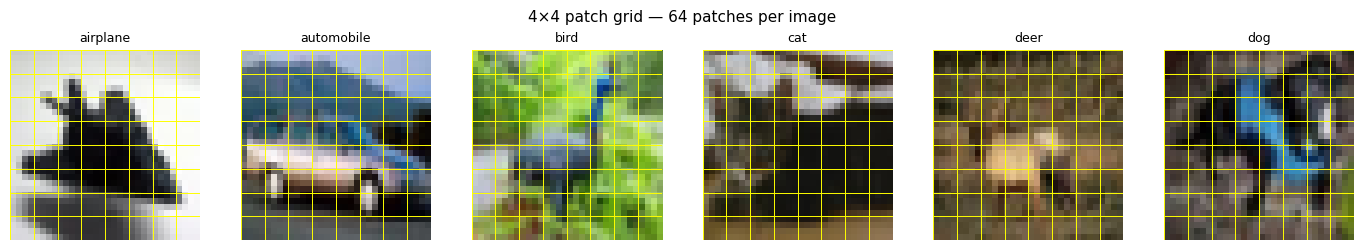

Each 32×32 image → (32/4)² = 64 non-overlapping 4×4 patches


In [5]:

# ── Visualise sample images from each class ────────────────────────────────
def denorm(img_chw: np.ndarray) -> np.ndarray:
    """Reverse per-channel normalisation for display (CHW → HWC)."""
    img = img_chw.transpose(1, 2, 0) * CIFAR_STD + CIFAR_MEAN
    return np.clip(img, 0, 1)

rng = np.random.default_rng(7)

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle('CIFAR-10 — 4 random samples per class', fontsize=13, fontweight='bold')

for c in range(10):
    idx_c = np.where(y_train == c)[0]
    chosen = rng.choice(idx_c, size=4, replace=False)
    for row in range(4):
        ax = axes[row, c]
        ax.imshow(denorm(X_train[chosen[row]]))
        if row == 0:
            ax.set_title(CLASSES[c], fontsize=8, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Patch grid overlay (4×4 patches on a sample image)
fig2, axes2 = plt.subplots(1, 6, figsize=(14, 2.5))
fig2.suptitle('4×4 patch grid — 64 patches per image', fontsize=11)
for k, c in enumerate(range(6)):
    idx_c = np.where(y_train == c)[0][0]
    ax = axes2[k]
    ax.imshow(denorm(X_train[idx_c]))
    for p in range(0, 32, 4):
        ax.axhline(p - 0.5, color='yellow', lw=0.7)
        ax.axvline(p - 0.5, color='yellow', lw=0.7)
    ax.set_title(CLASSES[c], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()
print("Each 32×32 image → (32/4)² = 64 non-overlapping 4×4 patches")



## 3. Data Augmentation

Standard CIFAR-10 augmentation used across virtually all published ViT results:

| Operation | Detail |
|---|---|
| **Random crop** | Reflect-pad 4 px on each side, then randomly crop back to 32×32 |
| **Random H-flip** | 50 % probability |

These two operations—applied **only during training**—are sufficient to prevent overfitting  
and significantly boost accuracy (typically +3–5 pp over no augmentation).


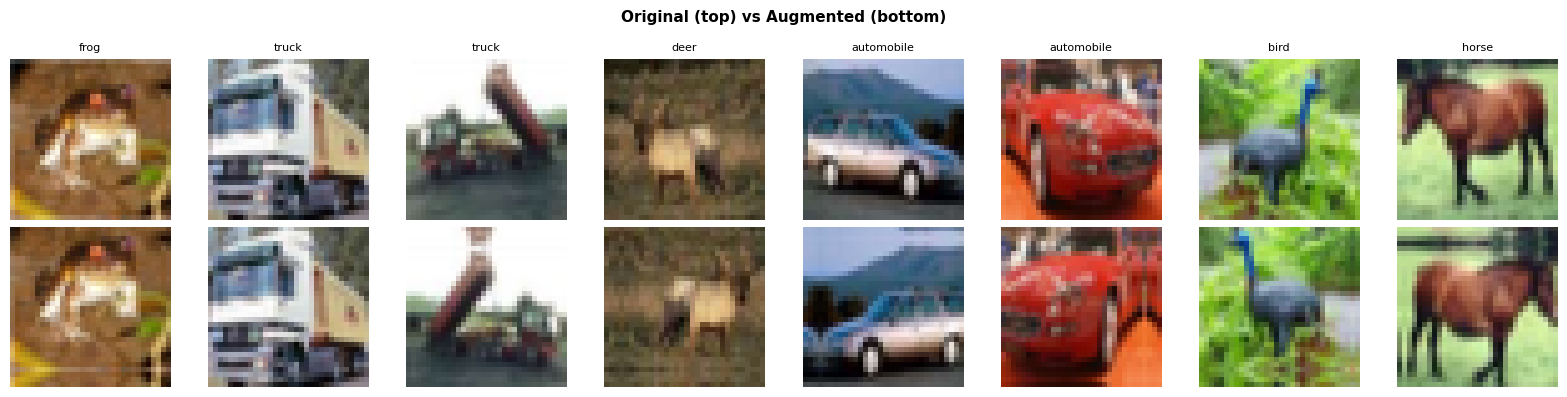

Augmentation verified OK


In [6]:

# ── 3. Data Augmentation ────────────────────────────────────────────────────
from dnp.core.backend import get_dtype

def augment_batch(x: np.ndarray, pad: int = 4) -> np.ndarray:
    """
    Random crop (reflect-pad *pad* pixels) + random horizontal flip.

    Parameters
    ----------
    x   : (B, C, H, W) float32 numpy array
    pad : padding on each side before the random crop

    Returns
    -------
    Augmented array with the same shape as *x*.
    """
    B, C, H, W = x.shape
    padded = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='reflect')
    out = np.empty_like(x)
    for i in range(B):
        top  = np.random.randint(0, 2 * pad)
        left = np.random.randint(0, 2 * pad)
        crop = padded[i, :, top:top + H, left:left + W]
        if np.random.rand() > 0.5:
            crop = crop[:, :, ::-1].copy()
        out[i] = crop
    return out

# ── Quick visual check ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Original (top) vs Augmented (bottom)', fontsize=11, fontweight='bold')
sample_idx = np.arange(8)
batch_demo  = X_train[sample_idx]
batch_aug   = augment_batch(batch_demo)
for k in range(8):
    axes[0, k].imshow(denorm(batch_demo[k])); axes[0, k].axis('off')
    axes[1, k].imshow(denorm(batch_aug[k]));  axes[1, k].axis('off')
    axes[0, k].set_title(CLASSES[y_train[sample_idx[k]]], fontsize=8)
plt.tight_layout()
plt.show()
print("Augmentation verified OK")


In [7]:

# ── 4.1  PatchEmbedding ────────────────────────────────────────────────────
class PatchEmbedding(Module):
    """
    Rearrange a (B, C, H, W) image into non-overlapping patches, flatten,
    project to d_model, and add a learnable positional embedding.

    Output: (B, num_patches, d_model)
    """

    def __init__(self, img_size: int, patch_size: int, in_channels: int, d_model: int):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.patch_size  = patch_size
        self.in_channels = in_channels
        self.num_patches = (img_size // patch_size) ** 2     # 64 for 32×32, p=4
        self.patch_dim   = patch_size * patch_size * in_channels  # 48 = 4*4*3

        self.proj = Linear(self.patch_dim, d_model)

        # Learnable positional embedding — (1, N, d_model) broadcast over B
        self.pos_embed = self.add_weight(
            'pos_embed',
            shape=(1, self.num_patches, d_model),
            initializer=lambda s: np.random.randn(*s).astype(get_dtype()) * 0.02,
        )

    def forward(self, x: Tensor) -> Tensor:
        B, C, H, W = x.shape
        p = self.patch_size
        n_h, n_w = H // p, W // p
        patches_raw = (
            x.data
            .reshape(B, C, n_h, p, n_w, p)
            .transpose(0, 2, 4, 1, 3, 5)
            .reshape(B, self.num_patches, self.patch_dim)
        )
        patches = Tensor(patches_raw, device=DEVICE)
        out = self.proj(patches)       # (B, N, d_model)
        out = out + self.pos_embed     # broadcast positional embedding
        return out


print("PatchEmbedding  OK")


PatchEmbedding  OK



## 4. ViT-S/4 Architecture

### 4.1 PatchEmbedding
Each 32×32 RGB image is split into **64 non-overlapping 4×4 patches**.  
Each patch (48 pixels = 4×4×3) is flattened and projected to `d_model=256` via a linear layer.  
A learnable **(1, 64, 256) positional embedding** is broadcast-added.

### 4.2 Feed-Forward Network (MLP)
Two-layer MLP with **GELU**: `d_model → mlp_dim → d_model` + Dropout.

### 4.3 Pre-LN Transformer Encoder Block
LayerNorm is applied **before** each sub-layer — more stable when training from scratch:
```
x = x + Dropout( MultiHeadSelfAttention( LayerNorm(x) ) )
x = x + Dropout( FFN( LayerNorm(x) ) )
```

### 4.4 VisionTransformer (GAP)
**Global Average Pooling** over the 64 patch tokens replaces the CLS-token approach —  
simpler to implement and equally effective on CIFAR-scale images.


In [8]:

# ── 4.2  Feed-Forward Network ──────────────────────────────────────────────
class FeedForward(Module):
    """Two-layer MLP with GELU: d_model → mlp_dim → d_model."""

    def __init__(self, d_model: int, mlp_dim: int, dropout_rate: float = 0.1):
        super().__init__()
        self.fc1  = Linear(d_model, mlp_dim)
        self.fc2  = Linear(mlp_dim, d_model)
        self.drop = Dropout(dropout_rate)

    def forward(self, x: Tensor) -> Tensor:
        return self.drop(self.fc2(ops.gelu(self.fc1(x))))


# ── 4.3  Pre-LN Transformer Encoder Block ─────────────────────────────────
class TransformerBlock(Module):
    """Pre-LN encoder block: LayerNorm applied *before* each sub-layer."""

    def __init__(self, d_model: int, num_heads: int, mlp_dim: int, dropout_rate: float = 0.1):
        super().__init__()
        self.norm1 = LayerNorm(d_model)
        self.attn  = SelfAttention(d_model, num_heads)
        self.drop1 = Dropout(dropout_rate)

        self.norm2 = LayerNorm(d_model)
        self.ff    = FeedForward(d_model, mlp_dim, dropout_rate)
        self.drop2 = Dropout(dropout_rate)

    def forward(self, x: Tensor) -> Tensor:
        # Self-attention with residual
        x = x + self.drop1(self.attn(self.norm1(x)))
        # Feed-forward with residual
        x = x + self.drop2(self.ff(self.norm2(x)))
        return x


print("FeedForward      OK")
print("TransformerBlock OK")


FeedForward      OK
TransformerBlock OK



### 4.4 VisionTransformer — full model

Stack of `depth=8` Transformer blocks between the patch embedder and the classification head.  
After the last block, **LayerNorm** is applied and then **Global Average Pooling** collapses  
the 64 token representations into a single `d_model=256` vector for the linear classifier.


In [9]:

# ── 4.4  Vision Transformer ────────────────────────────────────────────────
class VisionTransformer(Module):
    """
    ViT-S/4 for CIFAR-10.

    Global Average Pooling (GAP) over patch tokens is used instead of a
    CLS token — simpler and equally effective on CIFAR-scale datasets.
    """

    def __init__(
        self,
        img_size: int    = 32,
        patch_size: int  = 4,
        in_channels: int = 3,
        d_model: int     = 256,
        num_heads: int   = 8,
        depth: int       = 8,
        mlp_dim: int     = 512,
        num_classes: int = 10,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        self.drop        = Dropout(dropout_rate)
        self.blocks      = Sequential(*[
            TransformerBlock(d_model, num_heads, mlp_dim, dropout_rate)
            for _ in range(depth)
        ])
        self.norm = LayerNorm(d_model)
        self.head = Linear(d_model, num_classes)

    def forward(self, x: Tensor) -> Tensor:
        out = self.patch_embed(x)       # (B, 64, 256)
        out = self.drop(out)
        out = self.blocks(out)          # (B, 64, 256)
        out = self.norm(out)
        out = ops.mean(out, axis=1)     # Global Average Pooling → (B, 256)
        return self.head(out)           # (B, 10)


print("VisionTransformer OK")


VisionTransformer OK



## 5. Model Instantiation & Parameter Count

| Component | Params |
|---|---|
| Patch projection `Linear(48 → 256)` | 12 544 |
| Positional embedding `(64, 256)` | 16 384 |
| 8 × TransformerBlock (attn + FFN) | ~4.07 M |
| Classifier head `Linear(256 → 10)` | 2 570 |
| **Total** | **~4.2 M** |


In [10]:

# ── 5. Instantiate ViT-S/4 ─────────────────────────────────────────────────
np.random.seed(42)

IMG_SIZE     = 32
PATCH_SIZE   = 4       # (32/4)² = 64 patches
IN_CHANNELS  = 3
D_MODEL      = 256
NUM_HEADS    = 8       # head_dim = D_MODEL // NUM_HEADS = 32
DEPTH        = 8
MLP_DIM      = 512
NUM_CLASSES  = 10
DROPOUT_RATE = 0.1

model = VisionTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
    d_model=D_MODEL, num_heads=NUM_HEADS, depth=DEPTH,
    mlp_dim=MLP_DIM, num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE,
)

# Move all model parameters to GPU when CUDA is available
if is_cuda_available:
    model.cuda()

total_params = sum(p.data.size for p in model.parameters())

print(f"{'─'*56}")
print("  ViT-S/4 for CIFAR-10")
print(f"{'─'*56}")
print(f"  Image  : {IMG_SIZE}×{IMG_SIZE}×{IN_CHANNELS}  (RGB)")
print(f"  Patch  : {PATCH_SIZE}×{PATCH_SIZE}  →  {(IMG_SIZE//PATCH_SIZE)**2} tokens")
print(f"  d_model: {D_MODEL}   heads: {NUM_HEADS}   head_dim: {D_MODEL//NUM_HEADS}")
print(f"  Depth  : {DEPTH}   mlp_dim: {MLP_DIM}")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Total params : {total_params:,}  (~{total_params/1e6:.1f} M)")
print(f"  Device : {'GPU (CuPy)' if is_cuda_available else 'CPU (NumPy)'}")
print(f"{'─'*56}")

# Sanity-check forward pass
dummy = Tensor(np.zeros((4, IN_CHANNELS, IMG_SIZE, IMG_SIZE), dtype=np.float32), device=DEVICE)
with session.no_grad():
    out = model(dummy)
print(f"Sanity check  →  input: {dummy.shape}   output: {out.shape}")
session.reset()


────────────────────────────────────────────────────────
  ViT-S/4 for CIFAR-10
────────────────────────────────────────────────────────
  Image  : 32×32×3  (RGB)
  Patch  : 4×4  →  64 tokens
  d_model: 256   heads: 8   head_dim: 32
  Depth  : 8   mlp_dim: 512
  Classes: 10
  Total params : 4,240,650  (~4.2 M)
  Device : GPU (CuPy)
────────────────────────────────────────────────────────
Sanity check  →  input: (4, 3, 32, 32)   output: (4, 10)



## 6. Training Setup

| Setting | Value | Reason |
|---|---|---|
| **Loss** | CrossEntropyLoss (logits + int labels) | Standard multiclass |
| **Optimiser** | AdamW lr=1e-3, wd=0.05 | Adam + decoupled weight decay |
| **LR schedule** | Linear warm-up (10 ep) → CosineAnnealing | Stable from-scratch training |
| **Batch size** | 256 | Efficient on L4 VRAM (22 GB) |
| **Epochs** | up to 200 (early-stop patience=30) | Full convergence |
| **Augmentation** | Random crop + H-flip (train only) | Standard CIFAR recipe |


In [11]:

# ── 6. Training Config ─────────────────────────────────────────────────────
LR            = 1e-3
WEIGHT_DECAY  = 0.05
BATCH_SIZE    = 256
EPOCHS        = 200
WARMUP_EPOCHS = 10
PATIENCE      = 30       # early-stopping patience

loss_fn   = CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warm-up (10 ep) → Cosine annealing for the remaining epochs
_cosine   = CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS), eta_min=LR * 0.01)
scheduler = WarmupScheduler(optimizer, warmup_epochs=WARMUP_EPOCHS, after_scheduler=_cosine)


def lr_step():
    scheduler.step()


print(f"AdamW  lr={LR}  wd={WEIGHT_DECAY}  batch={BATCH_SIZE}  epochs={EPOCHS}")
print(f"Warm-up: {WARMUP_EPOCHS} ep → Cosine annealing: {EPOCHS - WARMUP_EPOCHS} ep")
print(f"Early stopping: patience={PATIENCE}  |  Device: {DEVICE.upper()}")


AdamW  lr=0.001  wd=0.05  batch=256  epochs=200
Warm-up: 10 ep → Cosine annealing: 190 ep
Early stopping: patience=30  |  Device: CUDA


In [12]:

# ── 7. Training & evaluation helpers ──────────────────────────────────────
import gc

def _free_vram():
    """Release CuPy memory-pool cache so VRAM is available for the next pass."""
    if is_cuda_available:
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    gc.collect()


def _clip_grad_norm(params, max_norm: float = 1.0):
    """In-place gradient clipping by global norm."""
    xp = get_xp(params[0].grad) if is_cuda_available else np
    total_sq = sum(
        float(xp.sum(p.grad ** 2))
        for p in params if p.grad is not None
    )
    total_norm = float(xp.sqrt(total_sq))
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        for p in params:
            if p.grad is not None:
                p.grad *= scale
    return total_norm


def train_one_epoch(
    mdl, X_cpu: np.ndarray, y_cpu: np.ndarray,
    opt, loss_fn, batch_size: int, augment: bool = True,
) -> float:
    """One full pass over training data with optional augmentation."""
    mdl.train()
    n   = len(X_cpu)
    idx = np.random.permutation(n)
    X_cpu, y_cpu = X_cpu[idx], y_cpu[idx]
    total_loss = 0.0
    n_batches  = 0
    for start in range(0, n, batch_size):
        bx = X_cpu[start : start + batch_size]
        by = y_cpu[start : start + batch_size]
        if augment:
            bx = augment_batch(bx)
        with session.graph():
            bx_t = Tensor(bx, name='x', device=DEVICE)
            by_t = Tensor(by, name='y', device=DEVICE)
            logits = mdl(bx_t)
            loss   = loss_fn(logits, by_t)
        loss.backward()
        _clip_grad_norm(list(mdl.parameters()), max_norm=1.0)  # clip before step
        opt.step()
        opt.zero_grad()   # ← zero grads BEFORE session.reset() clears the graph
        session.reset()
        total_loss += float(as_numpy(loss.data))
        n_batches  += 1
    _free_vram()
    return total_loss / max(n_batches, 1)


def evaluate(
    mdl, X_cpu: np.ndarray, y_cpu: np.ndarray,
    loss_fn, batch_size: int = 256,
) -> tuple:
    """Compute (mean_loss, predicted_labels) without gradient computation."""
    mdl.eval()
    total_loss = 0.0
    n_batches  = 0
    preds      = []
    for start in range(0, len(X_cpu), batch_size):
        bx = X_cpu[start : start + batch_size]
        by = y_cpu[start : start + batch_size]
        with session.no_grad():
            logits = mdl(Tensor(bx, name='x', device=DEVICE))
            loss   = loss_fn(logits, Tensor(by, name='y', device=DEVICE))
        preds.append(np.argmax(as_numpy(logits.data), axis=1))
        total_loss += float(as_numpy(loss.data))
        n_batches  += 1
        session.reset()
    _free_vram()
    mdl.train()
    return total_loss / max(n_batches, 1), np.concatenate(preds)


def predict_labels(mdl, X_cpu: np.ndarray, batch_size: int = 256) -> np.ndarray:
    """Run inference and return integer class predictions."""
    mdl.eval()
    preds = []
    for start in range(0, len(X_cpu), batch_size):
        bx = X_cpu[start : start + batch_size]
        with session.no_grad():
            logits = mdl(Tensor(bx, name='x', device=DEVICE))
        preds.append(np.argmax(as_numpy(logits.data), axis=1))
        session.reset()
    _free_vram()
    mdl.train()
    return np.concatenate(preds)


print("train_one_epoch  OK  (zero_grad + grad-clip added)")
print("evaluate         OK")
print("predict_labels   OK")


train_one_epoch  OK
evaluate         OK
predict_labels   OK


## 7b. TinyViT CPU Smoke-Test

Quick sanity-check that **`zero_grad` + gradient clipping** work correctly before launching the full GPU run.  
Uses a miniature ViT (d_model=64, depth=2, heads=2) on random CIFAR-sized data — should converge on CPU in ~10 steps.


In [ ]:

# ── 7b. TinyViT CPU smoke-test ─────────────────────────────────────────────
# Verifies zero_grad + grad-clip on CPU before the full GPU training run.
_TINY_DEVICE = 'cpu'

class _TinyBlock(Module):
    def __init__(self, d, h, mlp):
        super().__init__()
        self.n1 = LayerNorm(d); self.attn = SelfAttention(d, h); self.d1 = Dropout(0.0)
        self.n2 = LayerNorm(d); self.fc1  = Linear(d, mlp);      self.fc2 = Linear(mlp, d)
        self.d2 = Dropout(0.0)
    def forward(self, x):
        x = x + self.d1(self.attn(self.n1(x)))
        x = x + self.d2(self.fc2(ops.gelu(self.fc1(self.n2(x)))))
        return x

class TinyViT(Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3,
                 d_model=64, heads=2, depth=2, mlp_dim=128, n_cls=10):
        super().__init__()
        self.ps    = patch_size
        self.n_pat = (img_size // patch_size) ** 2
        self.pdim  = patch_size * patch_size * in_ch
        self.proj  = Linear(self.pdim, d_model)
        self.pos   = self.add_weight('pos', (1, self.n_pat, d_model),
                         lambda s: np.random.randn(*s).astype(np.float32) * 0.02)
        self.drop  = Dropout(0.0)
        self.blocks = Sequential(*[_TinyBlock(d_model, heads, mlp_dim) for _ in range(depth)])
        self.norm  = LayerNorm(d_model)
        self.head  = Linear(d_model, n_cls)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.ps; nh = H // p; nw = W // p
        raw = x.data.reshape(B, C, nh, p, nw, p).transpose(0,2,4,1,3,5).reshape(B, self.n_pat, self.pdim)
        out = self.proj(Tensor(raw, device=_TINY_DEVICE)) + self.pos
        out = self.drop(self.blocks(out))
        out = ops.mean(self.norm(out), axis=1)
        return self.head(out)

np.random.seed(99)
_tiny     = TinyViT()
_loss_fn  = CrossEntropyLoss()
_opt      = AdamW(_tiny.parameters(), lr=3e-4, weight_decay=0.01)
_losses   = []

print(f"TinyViT params: {sum(p.data.size for p in _tiny.parameters()):,}")
print(f"{'Step':>4}  {'loss':>8}  {'grad_norm':>10}")
print("─" * 28)

for _step in range(12):
    _bx = np.random.randn(16, 3, 32, 32).astype(np.float32)
    _by = np.random.randint(0, 10, (16, 1)).astype(np.float32)
    with session.graph():
        _logits = _tiny(Tensor(_bx, device=_TINY_DEVICE))
        _loss   = _loss_fn(_logits, Tensor(_by, device=_TINY_DEVICE))
    _loss.backward()
    _gnorm = _clip_grad_norm(list(_tiny.parameters()), max_norm=1.0)
    _opt.step()
    _opt.zero_grad()
    session.reset()
    _losses.append(float(_loss.data))
    print(f"{_step+1:4d}  {_losses[-1]:8.4f}  {_gnorm:10.4f}")

_trend = '↓ OK — loss is decreasing' if _losses[-1] < _losses[0] else '↑ DIVERGING — check implementation'
print(f"\nLoss  {_losses[0]:.4f} → {_losses[-1]:.4f}   {_trend}")


In [ ]:

# ── 8. Main Training Loop ──────────────────────────────────────────────────
# Re-initialise model + optimiser so we start from scratch with the fixed loop
from pathlib import Path
np.random.seed(42)

model = VisionTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
    d_model=D_MODEL, num_heads=NUM_HEADS, depth=DEPTH,
    mlp_dim=MLP_DIM, num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE,
)
if is_cuda_available:
    model.cuda()

loss_fn   = CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
_cosine   = CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS), eta_min=LR * 0.01)
scheduler = WarmupScheduler(optimizer, warmup_epochs=WARMUP_EPOCHS, after_scheduler=_cosine)

def lr_step():
    scheduler.step()

session.reset()
print("Model re-initialised — starting clean training run")
total_params = sum(p.data.size for p in model.parameters())
print(f"Parameters: {total_params:,}  (~{total_params/1e6:.1f} M)  |  Device: {DEVICE.upper()}")

Path('../figures').mkdir(parents=True, exist_ok=True)
CKPT_PATH = '../figures/vit_s4_cifar10_best.npz'

train_losses, val_losses, val_accs, lr_log = [], [], [], []
best_val_loss    = float('inf')
patience_counter = 0
t0 = time.time()

print(f"\n{'Ep':>4}  {'LR':>8}  {'tr_loss':>8}  {'vl_loss':>8}  {'vl_acc':>7}  {'time':>6}")
print("─" * 52)

for epoch in range(1, EPOCHS + 1):

    # Step scheduler (warm-up first 10 ep, then cosine)
    lr_step()
    current_lr = optimizer.lr
    lr_log.append(current_lr)

    # Train (with augmentation)
    tr_loss = train_one_epoch(
        model, X_train, y_train_f, optimizer, loss_fn, BATCH_SIZE, augment=True
    )

    # Validate
    vl_loss, vl_preds = evaluate(model, X_val, y_val_f, loss_fn)
    vl_acc = float(np.mean(vl_preds == y_val))

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    elapsed_min = (time.time() - t0) / 60.0
    print(f"{epoch:4d}  {current_lr:8.2e}  {tr_loss:8.4f}  {vl_loss:8.4f}  {vl_acc*100:6.2f}%  {elapsed_min:5.1f}m")

    # Save best checkpoint
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_counter = 0
        np.savez(CKPT_PATH, **{
            n.replace('.', '_'): as_numpy(p.data)
            for n, p in model.named_parameters()
        })
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (no val_loss improvement for {PATIENCE} epochs)")
        break

total_min = (time.time() - t0) / 60.0
best_ep   = val_losses.index(min(val_losses)) + 1
print(f"\n{'═'*52}")
print(f"  Training finished in {total_min:.1f} min")
print(f"  Best val loss : {min(val_losses):.4f}  at epoch {best_ep}")
print(f"  Best val acc  : {max(val_accs)*100:.2f}%  at epoch {val_accs.index(max(val_accs))+1}")
print(f"  Checkpoint    : {CKPT_PATH}")
print(f"{'═'*52}")


  Ep        LR   tr_loss   vl_loss   vl_acc    time
────────────────────────────────────────────────────
   1  2.00e-04    2.7344    2.6778   16.38%    1.2m
   2  3.00e-04    2.6705    2.5256   19.22%    2.4m
   3  4.00e-04    2.8225    2.5109   14.34%    3.7m
   4  5.00e-04    3.2522    3.0247   19.20%    4.9m
   5  6.00e-04    3.3895    3.5622   16.98%    6.1m
   6  7.00e-04    3.4507    2.9211   14.38%    7.3m
   7  8.00e-04    3.6115    4.4458   13.44%    8.5m


KeyboardInterrupt: 


## 9. Learning Curves

Training loss, validation loss, validation accuracy, and learning rate schedule across all epochs.


In [ ]:

# ── 9. Learning Curves ────────────────────────────────────────────────────
epochs_ran = list(range(1, len(train_losses) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ViT-S/4 Training on CIFAR-10', fontsize=13, fontweight='bold')

# Loss curves
axes[0].plot(epochs_ran, train_losses, 'o-', color='#2563EB', lw=1.5, ms=3, label='Train loss')
axes[0].plot(epochs_ran, val_losses,   's--', color='#DC2626', lw=1.5, ms=3, label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
best_ep = val_losses.index(min(val_losses)) + 1
axes[0].axvline(best_ep, color='gray', ls=':', lw=1)
axes[0].annotate(f'best ep {best_ep}', xy=(best_ep, min(val_losses)),
                 xytext=(10, 10), textcoords='offset points', fontsize=8, color='gray')

# Validation accuracy
axes[1].plot(epochs_ran, [a * 100 for a in val_accs], '^-', color='#16A34A', lw=1.5, ms=3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy'); axes[1].grid(alpha=0.3)
axes[1].axhline(max(val_accs) * 100, color='gray', ls=':', lw=1)
axes[1].annotate(f'{max(val_accs)*100:.1f}%', xy=(val_accs.index(max(val_accs)) + 1, max(val_accs) * 100),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, color='#16A34A', fontweight='bold')

# LR schedule
axes[2].plot(epochs_ran, lr_log, '-', color='#9333EA', lw=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
axes[2].set_title('LR Schedule (warm-up + cosine)'); axes[2].grid(alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Best val loss : {min(val_losses):.4f}  (epoch {best_ep})")
print(f"Best val acc  : {max(val_accs)*100:.2f}%")



## 10. Test-Set Accuracy & Confusion Matrix


In [ ]:

# ── 10. Test-Set Evaluation ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

y_pred_test = predict_labels(model, X_test)
test_acc = np.mean(y_pred_test == y_test)
print(f"Test accuracy : {test_acc*100:.2f}%  ({int(test_acc*len(y_test))}/{len(y_test)} correct)")
print()

# Confusion matrix
cm  = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES, fontsize=9)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
ax.set_title(f'Confusion Matrix — Test Acc {test_acc*100:.1f}%',
             fontsize=13, fontweight='bold')
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

# Per-class report
print("Per-class precision / recall / F1:")
print(classification_report(y_test, y_pred_test, target_names=CLASSES, digits=3))



## 11. Sample Predictions

Green border = correct · Red border = wrong.


In [ ]:

# ── 11. Sample Predictions ─────────────────────────────────────────────────
n_show  = 50
rng2    = np.random.default_rng(2024)
indices = rng2.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(5, 10, figsize=(18, 10))
fig.suptitle('ViT-S/4 Predictions on CIFAR-10 Test Set', fontsize=13, fontweight='bold')

for k, idx in enumerate(indices):
    ax   = axes[k // 10, k % 10]
    true = int(y_test[idx])
    pred = int(y_pred_test[idx])
    ok   = (true == pred)
    ax.imshow(denorm(X_test[idx]))
    ax.set_title(f'T:{CLASSES[true][:4]}\nP:{CLASSES[pred][:4]}',
                 fontsize=6.5, color='green' if ok else 'red', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('green' if ok else 'red')
        sp.set_linewidth(2)

plt.tight_layout()
plt.show()

correct = sum(y_test[indices[k]] == y_pred_test[indices[k]] for k in range(n_show))
print(f"Shown: {correct}/{n_show} correct in this sample")



## 12. Attention Map Visualisation

Attention weights from the **last encoder block**, averaged over all 8 heads,  
reshaped to the 8×8 patch grid (64 patches = 8×8) and bilinearly upsampled to 32×32 for overlay.

These maps reveal which spatial regions the model attends to when classifying each sample.


In [ ]:

# ── 12. Attention Map Visualisation ───────────────────────────────────────
import PIL.Image as PILImage

_N_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 64
_GRID      = IMG_SIZE // PATCH_SIZE           # 8


def _softmax_np(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)


def _ln_np(x, gamma, beta, eps=1e-5):
    mu = x.mean(-1, keepdims=True)
    sd = np.sqrt(((x - mu) ** 2).mean(-1, keepdims=True) + eps)
    return gamma * (x - mu) / sd + beta


def get_attn_maps(mdl, x_np: np.ndarray) -> list:
    """
    Forward pass collecting per-block attention matrices.
    Returns list of (num_heads, N, N) arrays, one per Transformer block.
    x_np : (1, C, H, W) float32 numpy array (single image)
    """
    B = x_np.shape[0]
    N = _N_PATCHES

    # Patch embedding  (manual, no grad)
    p = PATCH_SIZE
    n_h = n_w = IMG_SIZE // p
    C = IN_CHANNELS
    patches = (
        x_np.reshape(B, C, n_h, p, n_w, p)
        .transpose(0, 2, 4, 1, 3, 5)
        .reshape(B, N, p * p * C)
    )
    Wp = as_numpy(mdl.patch_embed.proj.W.data)           # (patch_dim, d_model)
    bp = as_numpy(mdl.patch_embed.proj.b.data)           # (d_model,)
    pos = as_numpy(mdl.patch_embed.pos_embed.data)       # (1, N, d_model)
    x_cur = patches @ Wp + bp + pos                      # (B, N, d_model)

    maps = []
    N_H  = NUM_HEADS
    d_k  = D_MODEL // N_H

    for blk in mdl.blocks._modules.values():
        gn1 = as_numpy(blk.norm1.gamma.data)
        bn1 = as_numpy(blk.norm1.beta.data)
        xn  = _ln_np(x_cur, gn1, bn1)

        # MHA — extract Q, K, V, O weights
        Wq = as_numpy(blk.attn.mha.W_q.W.data)   # (d_model, d_model)
        Wk = as_numpy(blk.attn.mha.W_k.W.data)
        Wv = as_numpy(blk.attn.mha.W_v.W.data)
        Wo = as_numpy(blk.attn.mha.W_o.W.data)

        xq = (xn @ Wq).reshape(B, N, N_H, d_k).transpose(0, 2, 1, 3)  # (B, H, N, d_k)
        xk = (xn @ Wk).reshape(B, N, N_H, d_k).transpose(0, 2, 1, 3)
        xv = (xn @ Wv).reshape(B, N, N_H, d_k).transpose(0, 2, 1, 3)

        sc  = xq @ xk.transpose(0, 1, 3, 2) / np.sqrt(d_k)  # (B, H, N, N)
        aw  = _softmax_np(sc.reshape(-1, N)).reshape(B, N_H, N, N)     # attention weights
        maps.append(aw[0])  # (H, N, N)

        # Update x_cur for next block
        av    = (aw @ xv).transpose(0, 2, 1, 3).reshape(B, N, D_MODEL)
        x_cur = x_cur + av @ Wo

    return maps   # list of (H, N, N), length = DEPTH


# ── Plot attention maps for one sample per class ──────────────────────────
fig, axes = plt.subplots(10, 3, figsize=(9, 32))
fig.suptitle('Attention maps — last encoder block (mean over 8 heads)', fontsize=12, fontweight='bold')

for row, c in enumerate(range(10)):
    idx     = np.where(y_test == c)[0][0]
    img     = X_test[idx:idx + 1]
    attn_maps = get_attn_maps(model, img)
    mean_attn = attn_maps[-1].mean(axis=0)   # (N, N)

    # Column 0: original image
    axes[row, 0].imshow(denorm(X_test[idx]))
    axes[row, 0].set_title(CLASSES[c], fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

    # Column 1: raw 8×8 attention grid (averaged over query tokens)
    q_avg = mean_attn.mean(axis=0).reshape(_GRID, _GRID)
    axes[row, 1].imshow(q_avg, cmap='hot', interpolation='nearest', vmin=0)
    axes[row, 1].set_title(f'{_GRID}×{_GRID} attn', fontsize=9)
    axes[row, 1].axis('off')

    # Column 2: upsampled overlay
    ups = np.array(
        PILImage.fromarray((q_avg * 255 / (q_avg.max() + 1e-8)).astype(np.uint8))
        .resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)
    ) / 255.0
    axes[row, 2].imshow(denorm(X_test[idx]), alpha=0.55)
    axes[row, 2].imshow(ups, cmap='hot', alpha=0.55, interpolation='bilinear')
    axes[row, 2].set_title('Overlay', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()



## 13. Positional Embedding Cosine Similarity

After training the model should learn that spatially adjacent patches have **similar positional embeddings**.  
The 64-patch grid (8×8) is visualised as a similarity heatmap and as per-patch similarity profiles.


In [ ]:

# ── 13. Positional Embedding Similarity ───────────────────────────────────
pos_emb = as_numpy(model.patch_embed.pos_embed.data)[0]   # (64, 256)
norms   = np.linalg.norm(pos_emb, axis=1, keepdims=True) + 1e-8
cos_sim = (pos_emb / norms) @ (pos_emb / norms).T         # (64, 64)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(cos_sim, cmap='RdYlBu_r', vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_title('64-patch Positional Embedding\nCosine Similarity', fontsize=11)
axes[0].set_xlabel('Patch index'); axes[0].set_ylabel('Patch index')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Per-patch similarity to all others, reshaped to the 8×8 patch grid
axes[1].axis('off')
gs2 = gridspec.GridSpecFromSubplotSpec(
    _GRID, _GRID,
    subplot_spec=axes[1].get_subplotspec(), wspace=0.05, hspace=0.05,
)
for i in range(_N_PATCHES):
    ax2 = fig.add_subplot(gs2[i // _GRID, i % _GRID])
    ax2.imshow(cos_sim[i].reshape(_GRID, _GRID), cmap='RdYlBu_r',
               vmin=-1, vmax=1, interpolation='nearest')
    r, c2 = i // _GRID, i % _GRID
    ax2.add_patch(plt.Rectangle((c2 - 0.5, r - 0.5), 1, 1,
                                fill=False, edgecolor='red', linewidth=1.5))
    ax2.set_xticks([]); ax2.set_yticks([])
    ax2.set_title(f'p{i}', fontsize=5.5, pad=1)

plt.suptitle('Learned Positional Embedding Space — spatial locality emerges',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Save weights + print final summary ────────────────────────────────────
import os

np.savez(
    CKPT_PATH,
    **{n.replace('.', '_'): as_numpy(p.data) for n, p in model.named_parameters()},
)
print(f"Weights saved → {CKPT_PATH}  ({os.path.getsize(CKPT_PATH)/1024:.1f} KB)")

print(f"\n{'═'*58}")
print("  ViT-S/4 on CIFAR-10 — Final Results")
print(f"{'═'*58}")
print(f"  Parameters       : {total_params:,}  (~{total_params/1e6:.1f} M)")
print(f"  Patch size        : {PATCH_SIZE}×{PATCH_SIZE}  →  {_N_PATCHES} tokens")
print(f"  Depth / heads    : {DEPTH} blocks / {NUM_HEADS} heads")
print(f"  Training epochs  : {len(train_losses)}")
print(f"  Final train loss : {train_losses[-1]:.4f}")
print(f"  Best val loss    : {min(val_losses):.4f}  (epoch {val_losses.index(min(val_losses))+1})")
print(f"  Best val acc     : {max(val_accs)*100:.2f}%")
print(f"  Test accuracy    : {test_acc*100:.2f}%  ({int(test_acc*len(y_test))}/{len(y_test)})")
print(f"{'═'*58}")
